# Configuration


In [13]:
# Simulation parameters
N_USERS = 5000

POWER_USER_RATIO = 0.10   # 10% power reviewers
MAX_REVIEWS = 50          # safety cap
HEAD_RATIO = 0.2

SENTIMENT_SCALE = [-2, -1, 0, 1, 2]

PRIOR_MEAN = 0.0
PRIOR_WEIGHT = 5.0

DB_SOURCE_PATH = "../data/app.sqlite"
DB_OUTPUT_PATH = "../data/app_simulated.sqlite"

RANDOM_SEED = 42


# Database safety checks


In [15]:
import os

print("Source DB:", DB_SOURCE_PATH)
print("Output DB:", DB_OUTPUT_PATH)

if not os.path.exists(DB_SOURCE_PATH):
    raise FileNotFoundError(f"Source DB does not exist: {DB_SOURCE_PATH}")

if os.path.exists(DB_OUTPUT_PATH):
    raise RuntimeError("Simulation DB already exists. Delete it manually or change DB_OUTPUT_PATH.")


Source DB: ../data/app.sqlite
Output DB: ../data/app_simulated.sqlite


# Database setup (copy & reset)


In [16]:
import sqlite3

source_uri = f"file:{DB_SOURCE_PATH}?mode=ro"
source_conn = sqlite3.connect(source_uri, uri=True)
source_conn.row_factory = sqlite3.Row

out_conn = sqlite3.connect(DB_OUTPUT_PATH)

STATIC_TABLES = [
    "node_type",
    "nodes",
    "taxonomy",
    "node_taxonomy",
    "edge_relations",
    "edges"
]

for table in STATIC_TABLES:
    schema_row = source_conn.execute(
        "SELECT sql FROM sqlite_master WHERE type='table' AND name=?", (table,)
    ).fetchone()
    if not schema_row or not schema_row["sql"]:
        raise RuntimeError(f"Missing schema for table: {table}")
    out_conn.execute(schema_row["sql"])
    rows = source_conn.execute(f"SELECT * FROM {table}").fetchall()
    if rows:
        cols = rows[0].keys()
        placeholders = ",".join(["?"] * len(cols))
        out_conn.executemany(
            f"INSERT INTO {table} ({','.join(cols)}) VALUES ({placeholders})",
            [tuple(row[col] for col in cols) for row in rows]
        )

DYNAMIC_TABLES = ["user", "review", "review_sentiment", "node_review_stats", "node_review_keywords"]
for table in DYNAMIC_TABLES:
    schema_row = source_conn.execute(
        "SELECT sql FROM sqlite_master WHERE type='table' AND name=?", (table,)
    ).fetchone()
    if not schema_row or not schema_row["sql"]:
        raise RuntimeError(f"Missing schema for table: {table}")
    out_conn.execute(schema_row["sql"])

out_conn.commit()
print("Database setup complete. Static tables copied; dynamic tables reset.")


Database setup complete. Static tables copied; dynamic tables reset.


# Load product nodes


In [17]:
product_nodes = out_conn.execute(
    "SELECT id, name FROM nodes WHERE type = 'product'"
).fetchall()

if not product_nodes:
    raise RuntimeError("No product nodes found (type = 'product').")

print("Product nodes:", len(product_nodes))


Product nodes: 25


# Review text templates


In [18]:
REVIEW_TEMPLATES = {
    -2: [
        "{product}은 너무 별로였다",
        "{product}은 다시는 안 사먹을 듯하다"
    ],
    -1: [
        "{product}은 기대보다 실망이었다"
    ],
     0: [
        "{product}은 그냥 무난하다",
        "{product}은 평타는 한다"
    ],
     1: [
        "{product}은 꽤 만족스러웠다"
    ],
     2: [
        "{product}은 정말 마음에 들었다",
        "{product}은 자주 사먹고 싶다"
    ]
}


# User generation


In [19]:
import random, math
from datetime import datetime, timezone

random.seed(RANDOM_SEED)

users = []
user_params = []


width = len(str(N_USERS - 1))

for i in range(N_USERS):
    user_id = f"user_{i:0{width}d}"
    password = "password"
    role = "user"

    # -----------------------------
    # Review count generation
    # -----------------------------
    if random.random() < POWER_USER_RATIO:
        # Power reviewer (long tail)
        n_reviews = int(random.lognormvariate(mu=1.2, sigma=1.0))
    else:
        # Casual reviewer (mostly 1)
        n_reviews = 1 if random.random() < 0.7 else 2

    n_reviews = max(1, min(n_reviews, MAX_REVIEWS))

    # Reviewer strictness
    strictness = random.gauss(0.0, 0.7)

    users.append((user_id, password, role))
    user_params.append({
        "user_id": user_id,
        "n_reviews": n_reviews,
        "strictness": strictness
    })


out_conn.executemany(
    "INSERT INTO user (user_id, password, role) VALUES (?, ?, ?)",
    users
)

user_id_map = {
    row[1]: row[0]
    for row in out_conn.execute("SELECT id, user_id FROM user").fetchall()
}

print("Inserted users:", len(users))


Inserted users: 5000


# Review generation


In [20]:
review_rows = []
sentiment_rows = []
now_iso = datetime.now(timezone.utc).isoformat()

nodes = product_nodes
random.shuffle(nodes)
head = nodes[:int(len(nodes) * HEAD_RATIO)]
tail = nodes[int(len(nodes) * HEAD_RATIO):]

for params in user_params:
    user_db_id = user_id_map[params["user_id"]]
    n_reviews = params["n_reviews"]
    strictness = params["strictness"]

    for _ in range(n_reviews):

        if random.random() < 0.6:
            entity_id, product_name = random.choice(head)
        else:
            entity_id, product_name = random.choice(tail)
        
        base_sentiment = random.choice(SENTIMENT_SCALE)
        adjusted = base_sentiment + strictness
        final_sentiment = max(-2, min(2, int(round(adjusted))))
        template = random.choice(REVIEW_TEMPLATES[final_sentiment])
        content = template.format(product=product_name)

        review_rows.append((user_db_id, content, entity_id, product_name, now_iso, now_iso))

        confidence = abs(final_sentiment) / 2.0
        sentiment_rows.append((None, final_sentiment, confidence, "simulated", "v1", now_iso))

out_conn.executemany(
    "INSERT INTO review (user_id, content, entity_id, entity_name, created_at, updated_at) "
    "VALUES (?, ?, ?, ?, ?, ?)",
    review_rows
)

review_ids = [row[0] for row in out_conn.execute("SELECT id FROM review").fetchall()]
if len(review_ids) != len(sentiment_rows):
    raise RuntimeError("Mismatch between reviews and sentiment rows.")

sentiment_rows_with_ids = []
for rid, srow in zip(review_ids, sentiment_rows):
    sentiment_rows_with_ids.append((rid, srow[1], srow[2], srow[3], srow[4], srow[5]))

out_conn.executemany(
    "INSERT INTO review_sentiment (review_id, sentiment_raw, confidence, method, version, created_at) "
    "VALUES (?, ?, ?, ?, ?, ?)",
    sentiment_rows_with_ids
)

out_conn.commit()
print("Inserted reviews:", len(review_rows))


Inserted reviews: 8561


# Node-level aggregation


In [21]:
agg_rows = out_conn.execute(
    "SELECT entity_id, COUNT(*) AS review_count, SUM(sentiment_raw) AS sentiment_sum, "
    "AVG(sentiment_raw) AS sentiment_avg "
    "FROM review r JOIN review_sentiment s ON s.review_id = r.id "
    "GROUP BY entity_id"
).fetchall()

node_stats_rows = []
for row in agg_rows:
    node_id = row[0]
    review_count = row[1]
    sentiment_sum = row[2]
    sentiment_avg = row[3]
    bayes_score = (PRIOR_MEAN * PRIOR_WEIGHT + sentiment_sum) / (PRIOR_WEIGHT + review_count)
    node_stats_rows.append(
        (node_id, review_count, sentiment_sum, sentiment_avg, bayes_score, None, None, now_iso)
    )

out_conn.executemany(
    "INSERT INTO node_review_stats (node_id, review_count, sentiment_sum, sentiment_avg, bayes_score, "
    "weighted_count, weighted_sentiment_sum, updated_at) "
    "VALUES (?, ?, ?, ?, ?, ?, ?, ?)",
    node_stats_rows
)

out_conn.commit()
print("Inserted node_review_stats rows:", len(node_stats_rows))


Inserted node_review_stats rows: 25


# Sanity checks


In [22]:
user_count = out_conn.execute("SELECT COUNT(*) FROM user").fetchone()[0]
review_count = out_conn.execute("SELECT COUNT(*) FROM review").fetchone()[0]

print("Total users:", user_count)
print("Total reviews:", review_count)

print("\nTop 10 products by review_count:")
for row in out_conn.execute(
    "SELECT n.name, nrs.review_count "
    "FROM node_review_stats nrs JOIN nodes n ON n.id = nrs.node_id "
    "ORDER BY nrs.review_count DESC LIMIT 10"
).fetchall():
    print(row[0], row[1])

print("\nTop 10 products by bayes_score:")
for row in out_conn.execute(
    "SELECT n.name, nrs.bayes_score "
    "FROM node_review_stats nrs JOIN nodes n ON n.id = nrs.node_id "
    "ORDER BY nrs.bayes_score DESC LIMIT 10"
).fetchall():
    print(row[0], f"{row[1]:.3f}")

print("\nExample user and reviews:")
example_user = out_conn.execute("SELECT id, user_id FROM user LIMIT 1").fetchone()
print("User:", example_user[1])
for row in out_conn.execute(
    "SELECT r.content, r.entity_name FROM review r WHERE r.user_id = ? LIMIT 5",
    (example_user[0],)
).fetchall():
    print("-", row[0])


Total users: 5000
Total reviews: 8561

Top 10 products by review_count:
교촌간장 1075
교촌레드 1068
고추바사삭 (굽네치킨) 1019
풀무원 오징어부추전 1017
카덴 정호영 가쓰오우동 994
풀무원 감자전 196
K마라치킨 (처갓집 양념치킨) 183
한돈 그릴 비엔나 182
이마트 참치회 180
이마트 광어회 176

Top 10 products by bayes_score:
산토리 나마비루 0.246
맵소디 (BBQ) 0.236
쏘마치 (BHC) 0.154
이마트 델리 0.135
이마트 광어회 0.105
CJ고메 대가 탕수육 0.099
피코크 핫순살치킨 0.092
이마트 광어세꼬시 0.073
이마트 참치회 0.065
피코크 커스터드쿠키슈 0.052

Example user and reviews:
User: user_0000
- 교촌간장은 기대보다 실망이었다


# App integration notes

- This DB is disposable simulation data for local testing.
- The app can switch DBs by changing a path.

- Example:

```ts
export const DB_PATH =
  process.env.DB_PATH ?? "data/app_simulated.sqlite";
```

- Do NOT use this DB in production.


# Optional cleanup (commented out)


In [14]:
# DANGER ZONE – optional cleanup
# Uncomment only if you want to delete the simulated DB

import os
os.remove(DB_OUTPUT_PATH)
print("Deleted simulated DB:", DB_OUTPUT_PATH)


Deleted simulated DB: ../data/app_simulated.sqlite


# TESTING

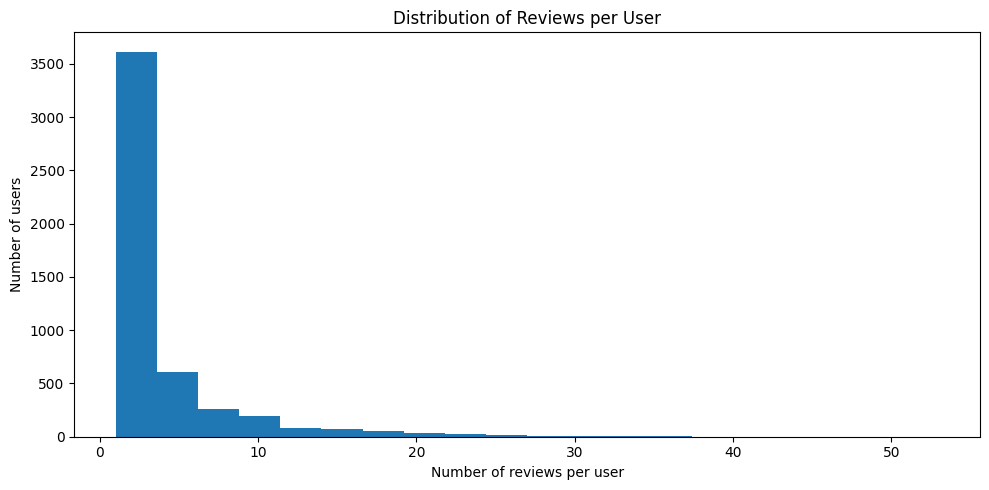

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------
# Parameters
# -----------------------------
N_USERS = 5000
AVG_REVIEWS_PER_USER = 3
STD_REVIEWS_PER_USER = 5

# -----------------------------
# Derive negative binomial params
# mean = r * (1 - p) / p
# var  = r * (1 - p) / p^2
# -----------------------------
variance = STD_REVIEWS_PER_USER ** 2
p = AVG_REVIEWS_PER_USER / variance
r = AVG_REVIEWS_PER_USER * p / (1 - p)

# -----------------------------
# Sample reviews (zero-truncated)
# -----------------------------
reviews = np.random.negative_binomial(r, p, size=N_USERS)
reviews = np.maximum(reviews, 1)  # ensure at least 1 review per reviewer

# -----------------------------
# Count frequencies
# -----------------------------
counts = Counter(reviews)
x = sorted(counts.keys())
y = [counts[k] for k in x]

# -----------------------------
# Plot
# -----------------------------
NUM_BINS = 20

plt.figure(figsize=(10, 5))
plt.hist(reviews, bins=NUM_BINS)
plt.xlabel("Number of reviews per user")
plt.ylabel("Number of users")
plt.title("Distribution of Reviews per User")
plt.tight_layout()
plt.show()